<a href="https://colab.research.google.com/github/siddKatiyar09/Credit-Card-Fraud-Detection/blob/main/credit_card_fraud_detection_simple.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Credit Card Fraud Detection

This beginner-friendly project builds a fraud detection model that can run on a normal
laptop. It uses clear Python code, useful visualizations, and two simple models.

## Project goals

- Understand the highly imbalanced dataset.
- Visualize fraud patterns.
- Train a Logistic Regression baseline.
- Train a small neural network.
- Compare models using fraud-focused metrics.

> `Class = 0` means a normal transaction and `Class = 1` means fraud.

## 1. Import libraries

The project uses standard data-science libraries and scikit-learn. TensorFlow is not
required, which makes installation and training easier on a laptop.

In [22]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_columns", 35)
pd.set_option("display.float_format", "{:,.4f}".format)

DATA_PATH = Path("/content/creditcard.csv.zip")

print("Libraries loaded successfully.")
print(f"Dataset path: {DATA_PATH.resolve()}")

Libraries loaded successfully.
Dataset path: /content/creditcard.csv.zip


## 2. Load the dataset

Pandas can read the compressed ZIP file directly, so the dataset does not need to be
extracted first.

In [23]:
transactions = pd.read_csv(DATA_PATH)

print(f"Rows: {transactions.shape[0]:,}")
print(f"Columns: {transactions.shape[1]}")
display(transactions.head())

Rows: 284,807
Columns: 31


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0000,-1.3598,-0.0728,2.5363,1.3782,-0.3383,0.4624,0.2396,0.0987,0.3638,0.0908,-0.5516,-0.6178,-0.9914,-0.3112,1.4682,-0.4704,0.2080,0.0258,0.4040,0.2514,-0.0183,0.2778,-0.1105,0.0669,0.1285,-0.1891,0.1336,-0.0211,149.6200,0
1,0.0000,1.1919,0.2662,0.1665,0.4482,0.0600,-0.0824,-0.0788,0.0851,-0.2554,-0.1670,1.6127,1.0652,0.4891,-0.1438,0.6356,0.4639,-0.1148,-0.1834,-0.1458,-0.0691,-0.2258,-0.6387,0.1013,-0.3398,0.1672,0.1259,-0.0090,0.0147,2.6900,0
2,1.0000,-1.3584,-1.3402,1.7732,0.3798,-0.5032,1.8005,0.7915,0.2477,-1.5147,0.2076,0.6245,0.0661,0.7173,-0.1659,2.3459,-2.8901,1.1100,-0.1214,-2.2619,0.5250,0.2480,0.7717,0.9094,-0.6893,-0.3276,-0.1391,-0.0554,-0.0598,378.6600,0
3,1.0000,-0.9663,-0.1852,1.7930,-0.8633,-0.0103,1.2472,0.2376,0.3774,-1.3870,-0.0550,-0.2265,0.1782,0.5078,-0.2879,-0.6314,-1.0596,-0.6841,1.9658,-1.2326,-0.2080,-0.1083,0.0053,-0.1903,-1.1756,0.6474,-0.2219,0.0627,0.0615,123.5000,0
4,2.0000,-1.1582,0.8777,1.5487,0.4030,-0.4072,0.0959,0.5929,-0.2705,0.8177,0.7531,-0.8228,0.5382,1.3459,-1.1197,0.1751,-0.4514,-0.2370,-0.0382,0.8035,0.4085,-0.0094,0.7983,-0.1375,0.1413,-0.2060,0.5023,0.2194,0.2152,69.9900,0


## 3. Understand and clean the data

We check data types, missing values, duplicate rows, and the target values before modeling.

In [24]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [25]:
quality_summary = pd.DataFrame(
    {
        "Check": ["Missing values", "Duplicate rows", "Normal transactions", "Fraud transactions"],
        "Count": [
            transactions.isna().sum().sum(),
            transactions.duplicated().sum(),
            (transactions["Class"] == 0).sum(),
            (transactions["Class"] == 1).sum(),
        ],
    }
)

display(quality_summary)

,Check,Count
0,Missing values,0
1,Duplicate rows,1081
2,Normal transactions,284315
3,Fraud transactions,492


In [26]:
clean_data = transactions.drop_duplicates().copy()
clean_data["Hour"] = ((clean_data["Time"] // 3600) % 24).astype(int)
clean_data["LogAmount"] = np.log1p(clean_data["Amount"])

print(f"Rows after removing duplicates: {len(clean_data):,}")
print(f"Fraud cases after cleaning: {clean_data['Class'].sum():,}")
display(clean_data.head())

Rows after removing duplicates: 283,726
Fraud cases after cleaning: 473


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class,Hour,LogAmount
0,0.0000,-1.3598,-0.0728,2.5363,1.3782,-0.3383,0.4624,0.2396,0.0987,0.3638,0.0908,-0.5516,-0.6178,-0.9914,-0.3112,1.4682,-0.4704,0.2080,0.0258,0.4040,0.2514,-0.0183,0.2778,-0.1105,0.0669,0.1285,-0.1891,0.1336,-0.0211,149.6200,0,0,5.0148
1,0.0000,1.1919,0.2662,0.1665,0.4482,0.0600,-0.0824,-0.0788,0.0851,-0.2554,-0.1670,1.6127,1.0652,0.4891,-0.1438,0.6356,0.4639,-0.1148,-0.1834,-0.1458,-0.0691,-0.2258,-0.6387,0.1013,-0.3398,0.1672,0.1259,-0.0090,0.0147,2.6900,0,0,1.3056
2,1.0000,-1.3584,-1.3402,1.7732,0.3798,-0.5032,1.8005,0.7915,0.2477,-1.5147,0.2076,0.6245,0.0661,0.7173,-0.1659,2.3459,-2.8901,1.1100,-0.1214,-2.2619,0.5250,0.2480,0.7717,0.9094,-0.6893,-0.3276,-0.1391,-0.0554,-0.0598,378.6600,0,0,5.9393
3,1.0000,-0.9663,-0.1852,1.7930,-0.8633,-0.0103,1.2472,0.2376,0.3774,-1.3870,-0.0550,-0.2265,0.1782,0.5078,-0.2879,-0.6314,-1.0596,-0.6841,1.9658,-1.2326,-0.2080,-0.1083,0.0053,-0.1903,-1.1756,0.6474,-0.2219,0.0627,0.0615,123.5000,0,0,4.8243
4,2.0000,-1.1582,0.8777,1.5487,0.4030,-0.4072,0.0959,0.5929,-0.2705,0.8177,0.7531,-0.8228,0.5382,1.3459,-1.1197,0.1751,-0.4514,-0.2370,-0.0382,0.8035,0.4085,-0.0094,0.7983,-0.1375,0.1413,-0.2060,0.5023,0.2194,0.2152,69.9900,0,0,4.2625


## 4. Fraud distribution

Fraud is extremely rare. The logarithmic scale makes both classes visible in one chart.

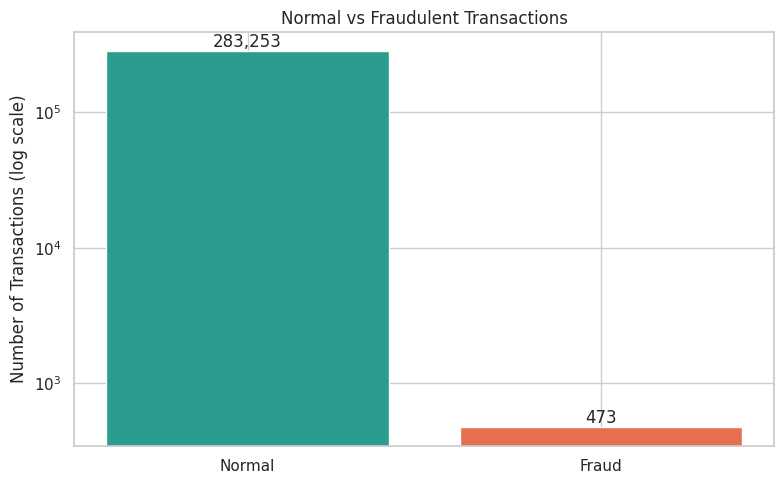

Fraud rate: 0.1667%


In [27]:
class_counts = clean_data["Class"].value_counts().sort_index()
fraud_rate = clean_data["Class"].mean() * 100

plt.figure(figsize=(8, 5))
bars = plt.bar(["Normal", "Fraud"], class_counts.values, color=["#2a9d8f", "#e76f51"])
plt.yscale("log")
plt.title("Normal vs Fraudulent Transactions")
plt.ylabel("Number of Transactions (log scale)")
for bar, value in zip(bars, class_counts.values):
    plt.text(bar.get_x() + bar.get_width() / 2, value, f"{value:,}", ha="center", va="bottom")
plt.tight_layout()
plt.show()

print(f"Fraud rate: {fraud_rate:.4f}%")

## 5. Transaction amount by class

We use a log-transformed amount because transaction values are strongly skewed.

,count,mean,median,max
Class,,,,
Normal,283253,88.4136,22.0000,"25,691.1600"
Fraud,473,123.8719,9.8200,"2,125.8700"


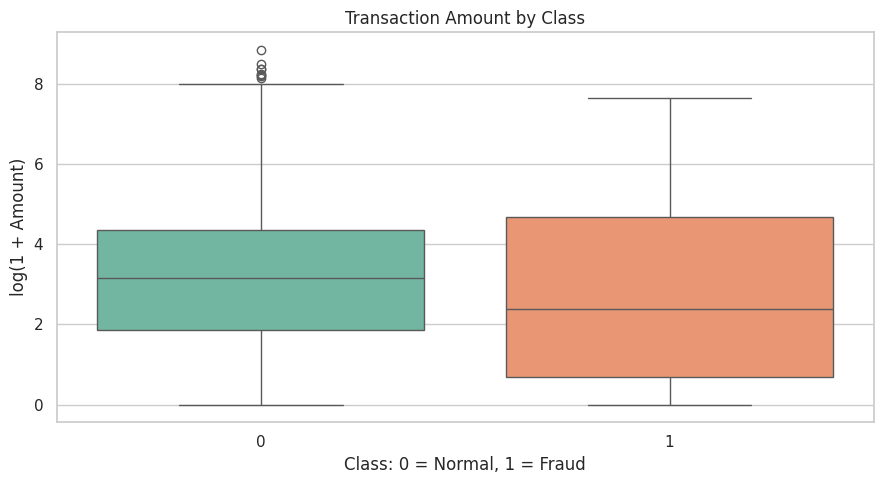

In [28]:
amount_summary = (
    clean_data.groupby("Class")["Amount"]
    .agg(["count", "mean", "median", "max"])
    .rename(index={0: "Normal", 1: "Fraud"})
)
display(amount_summary)

plot_sample = pd.concat(
    [
        clean_data[clean_data["Class"] == 0].sample(5000, random_state=RANDOM_STATE),
        clean_data[clean_data["Class"] == 1],
    ]
)

plt.figure(figsize=(9, 5))
sns.boxplot(data=plot_sample, x="Class", y="LogAmount", hue="Class", legend=False)
plt.title("Transaction Amount by Class")
plt.xlabel("Class: 0 = Normal, 1 = Fraud")
plt.ylabel("log(1 + Amount)")
plt.tight_layout()
plt.show()

## 6. Hourly fraud pattern

The original `Time` column is converted into an hour from 0 to 23 for easier interpretation.

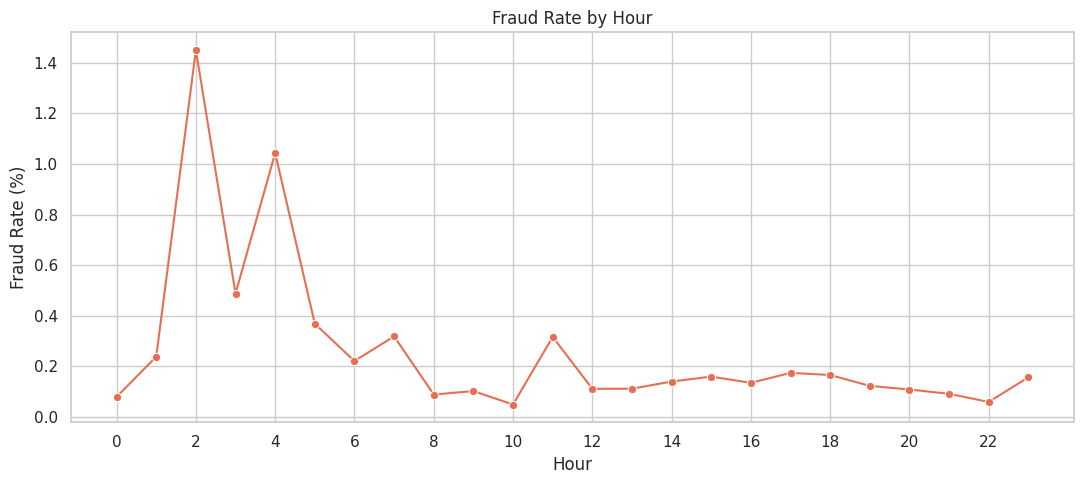

,Hour,Transactions,Fraud_Cases,Fraud_Rate_Percent
0,0,7647,6,0.0785
1,1,4208,10,0.2376
2,2,3308,48,1.4510
3,3,3487,17,0.4875
4,4,2204,23,1.0436
5,5,2988,11,0.3681
6,6,4082,9,0.2205
7,7,7233,23,0.3180
8,8,10232,9,0.0880
9,9,15767,16,0.1015


In [29]:
hourly_pattern = (
    clean_data.groupby("Hour")["Class"]
    .agg(Transactions="count", Fraud_Cases="sum", Fraud_Rate="mean")
    .reset_index()
)
hourly_pattern["Fraud_Rate_Percent"] = hourly_pattern["Fraud_Rate"] * 100

plt.figure(figsize=(11, 5))
sns.lineplot(data=hourly_pattern, x="Hour", y="Fraud_Rate_Percent", marker="o", color="#e76f51")
plt.title("Fraud Rate by Hour")
plt.xlabel("Hour")
plt.ylabel("Fraud Rate (%)")
plt.xticks(range(0, 24, 2))
plt.tight_layout()
plt.show()

display(hourly_pattern[["Hour", "Transactions", "Fraud_Cases", "Fraud_Rate_Percent"]])

## 7. Correlation heatmap

The heatmap focuses on the features most strongly related to the fraud target.
Correlation does not prove causation, but it helps identify useful patterns.

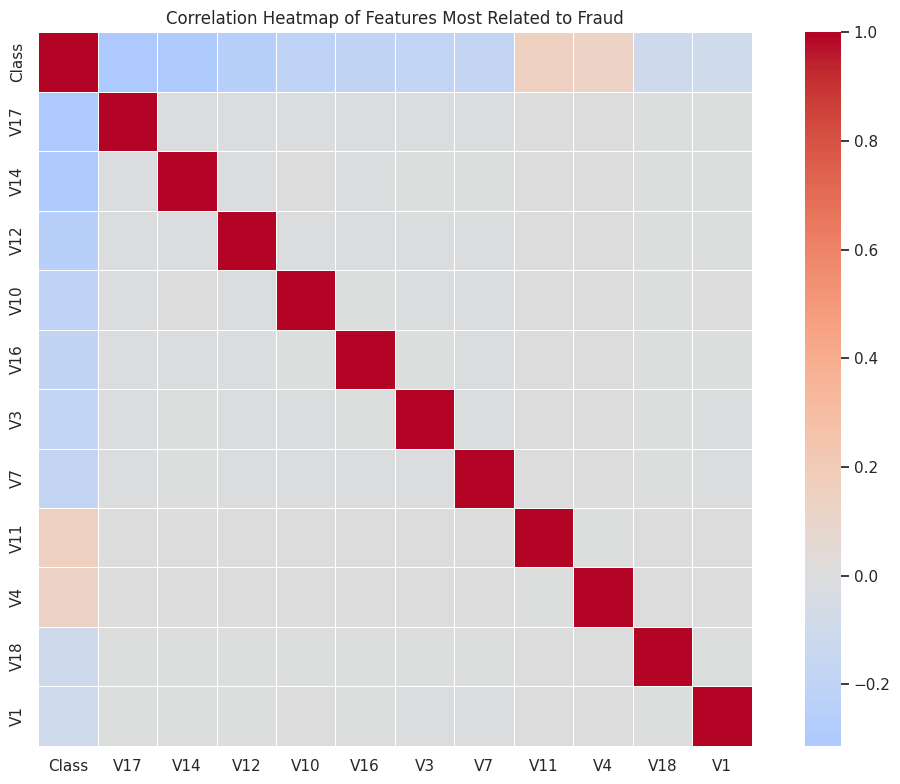

,Absolute Correlation with Class
Class,1.0000
V17,0.3135
V14,0.2934
V12,0.2507
V10,0.2070
V16,0.1872
V3,0.1823
V7,0.1723
V11,0.1491
V4,0.1293


In [30]:
numeric_data = clean_data.drop(columns=["Hour", "LogAmount"])
class_correlations = numeric_data.corr()["Class"].abs().sort_values(ascending=False)
heatmap_features = class_correlations.head(12).index

plt.figure(figsize=(11, 8))
sns.heatmap(
    numeric_data[heatmap_features].corr(),
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.4,
)
plt.title("Correlation Heatmap of Features Most Related to Fraud")
plt.tight_layout()
plt.show()

display(class_correlations.head(12).to_frame("Absolute Correlation with Class"))

## 8. PCA feature visualization

`V1` and `V2` are anonymized PCA features. A sample of normal transactions is used so the
chart stays readable.

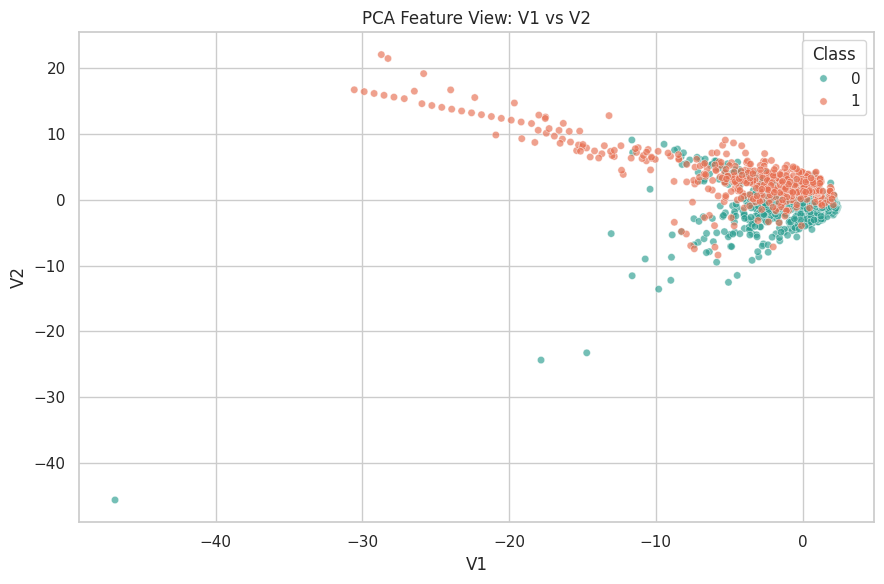

In [31]:
pca_sample = pd.concat(
    [
        clean_data[clean_data["Class"] == 0].sample(4000, random_state=RANDOM_STATE),
        clean_data[clean_data["Class"] == 1],
    ]
)

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=pca_sample,
    x="V1",
    y="V2",
    hue="Class",
    palette={0: "#2a9d8f", 1: "#e76f51"},
    alpha=0.65,
    s=28,
)
plt.title("PCA Feature View: V1 vs V2")
plt.tight_layout()
plt.show()

## 9. Prepare training and testing data

The test data keeps the original fraud imbalance. Only the training data is balanced,
which prevents information from the test set leaking into model training.

In [32]:
model_features = ["Time", *[f"V{number}" for number in range(1, 29)], "Amount"]
X = clean_data[model_features]
y = clean_data["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

split_summary = pd.DataFrame(
    {
        "Dataset": ["Training", "Testing"],
        "Rows": [len(X_train), len(X_test)],
        "Fraud Cases": [y_train.sum(), y_test.sum()],
        "Fraud Rate (%)": [y_train.mean() * 100, y_test.mean() * 100],
    }
)
display(split_summary)

,Dataset,Rows,Fraud Cases,Fraud Rate (%)
0,Training,226980,378,0.1665
1,Testing,56746,95,0.1674


## 10. Balance only the training data

We keep all fraud cases and randomly select five normal transactions for every fraud case.
This makes training faster while still keeping more normal than fraudulent examples.

In [33]:
training_table = pd.concat([X_train, y_train.rename("Class")], axis=1)
fraud_training = training_table[training_table["Class"] == 1]
normal_training = training_table[training_table["Class"] == 0].sample(
    n=len(fraud_training) * 5,
    random_state=RANDOM_STATE,
)

balanced_training = pd.concat([fraud_training, normal_training]).sample(
    frac=1,
    random_state=RANDOM_STATE,
)

X_train_balanced = balanced_training[model_features]
y_train_balanced = balanced_training["Class"]

balance_summary = pd.DataFrame(
    {
        "Class": ["Normal", "Fraud"],
        "Training Rows": [
            (y_train_balanced == 0).sum(),
            (y_train_balanced == 1).sum(),
        ],
    }
)
display(balance_summary)

,Class,Training Rows
0,Normal,1890
1,Fraud,378


## 11. Scale the features

Scaling helps both Logistic Regression and the neural network learn from features that
have different numeric ranges.

In [34]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_balanced)
X_test_scaled = scaler.transform(X_test)

print(f"Balanced training shape: {X_train_scaled.shape}")
print(f"Original test shape: {X_test_scaled.shape}")

Balanced training shape: (2268, 30)
Original test shape: (56746, 30)


## 12. Train the models

The small neural network has two hidden layers and uses early stopping so it does not
train longer than necessary.

In [35]:
logistic_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
logistic_model.fit(X_train_scaled, y_train_balanced)

neural_network = MLPClassifier(
    hidden_layer_sizes=(32, 16),
    activation="relu",
    batch_size=128,
    learning_rate_init=0.001,
    max_iter=50,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=6,
    random_state=RANDOM_STATE,
)
neural_network.fit(X_train_scaled, y_train_balanced)

print("Models trained successfully.")
print(f"Neural network iterations: {neural_network.n_iter_}")

Models trained successfully.
Neural network iterations: 14


## 13. Compare model performance

Accuracy is included, but precision, recall, F1, ROC-AUC, and PR-AUC are more useful for
this highly imbalanced fraud problem.

In [36]:
models = {
    "Logistic Regression": logistic_model,
    "Small Neural Network": neural_network,
}

model_results = []
model_outputs = {}

for model_name, model in models.items():
    probabilities = model.predict_proba(X_test_scaled)[:, 1]
    predictions = (probabilities >= 0.50).astype(int)
    matrix = confusion_matrix(y_test, predictions)
    true_negative, false_positive, false_negative, true_positive = matrix.ravel()

    model_results.append(
        {
            "Model": model_name,
            "Accuracy": (predictions == y_test).mean(),
            "Precision": precision_score(y_test, predictions, zero_division=0),
            "Recall": recall_score(y_test, predictions, zero_division=0),
            "F1 Score": f1_score(y_test, predictions, zero_division=0),
            "ROC-AUC": roc_auc_score(y_test, probabilities),
            "PR-AUC": average_precision_score(y_test, probabilities),
            "False Positives": false_positive,
            "False Negatives": false_negative,
        }
    )
    model_outputs[model_name] = {
        "probabilities": probabilities,
        "predictions": predictions,
        "matrix": matrix,
    }

results = pd.DataFrame(model_results).sort_values("F1 Score", ascending=False)
display(results.round(4))

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC,False Positives,False Negatives
1,Small Neural Network,0.9980,0.4491,0.7895,0.5725,0.9641,0.7011,92,20
0,Logistic Regression,0.9944,0.2058,0.8211,0.3291,0.9611,0.6576,301,17


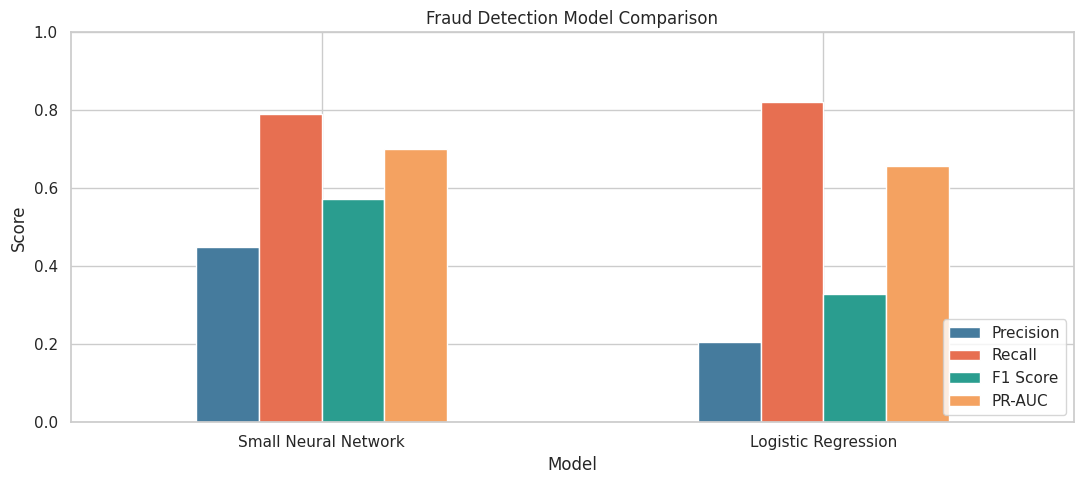

In [37]:
metric_columns = ["Precision", "Recall", "F1 Score", "PR-AUC"]
chart_data = results.set_index("Model")[metric_columns]

chart_data.plot(kind="bar", figsize=(11, 5), color=["#457b9d", "#e76f51", "#2a9d8f", "#f4a261"])
plt.title("Fraud Detection Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 14. Confusion matrices

A false negative is a fraud transaction that the model misses. A false positive is a
normal transaction sent for unnecessary review.

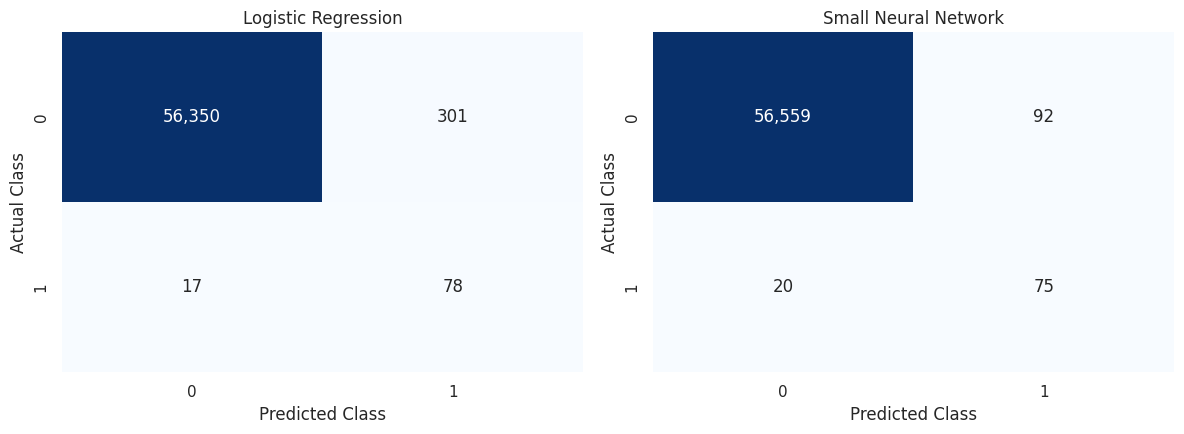

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for axis, (model_name, output) in zip(axes, model_outputs.items()):
    sns.heatmap(
        output["matrix"],
        annot=True,
        fmt=",d",
        cmap="Blues",
        cbar=False,
        ax=axis,
    )
    axis.set_title(model_name)
    axis.set_xlabel("Predicted Class")
    axis.set_ylabel("Actual Class")

plt.tight_layout()
plt.show()

## 15. ROC and precision-recall curves

The precision-recall curve is especially important because fraud is the rare class.

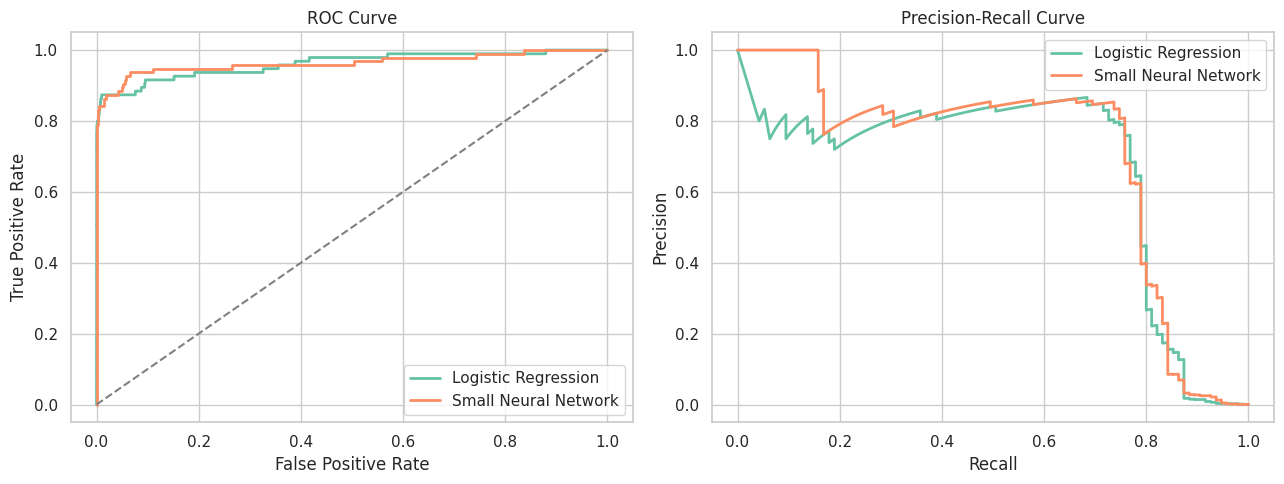

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for model_name, output in model_outputs.items():
    false_positive_rate, true_positive_rate, _ = roc_curve(y_test, output["probabilities"])
    precision_values, recall_values, _ = precision_recall_curve(y_test, output["probabilities"])

    axes[0].plot(false_positive_rate, true_positive_rate, linewidth=2, label=model_name)
    axes[1].plot(recall_values, precision_values, linewidth=2, label=model_name)

axes[0].plot([0, 1], [0, 1], "--", color="gray")
axes[0].set_title("ROC Curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

axes[1].set_title("Precision-Recall Curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()

plt.tight_layout()
plt.show()

## 16. Detailed report for the best model

The model with the highest F1 score is selected only for this simple comparison.
A real bank may choose a different threshold based on investigation cost and fraud loss.

In [40]:
best_model_name = results.iloc[0]["Model"]
best_predictions = model_outputs[best_model_name]["predictions"]

print(f"Best model by F1 score: {best_model_name}")
print()
print(classification_report(y_test, best_predictions, target_names=["Normal", "Fraud"]))

Best model by F1 score: Small Neural Network

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56651
       Fraud       0.45      0.79      0.57        95

    accuracy                           1.00     56746
   macro avg       0.72      0.89      0.79     56746
weighted avg       1.00      1.00      1.00     56746



## 17. Business interpretation

- **False negatives are expensive:** missed fraud can cause direct financial loss and customer harm.
- **False positives create workload:** normal transactions may be delayed or reviewed unnecessarily.
- **Recall helps capture fraud:** higher recall means fewer fraudulent transactions are missed.
- **Precision controls alerts:** higher precision means investigators receive fewer unnecessary cases.
- **Thresholds are business decisions:** a bank can lower the threshold to catch more fraud or raise it to reduce false alarms.

## Project limitations

- The feature names `V1` to `V28` are anonymized, which limits business explanation.
- Under-sampling removes many normal training examples.
- Fraud behavior changes over time, so a production model would require regular retraining.
- This notebook is an educational project and is not a production banking system.

## Conclusion

This project demonstrates fraud detection workflow. It
includes data cleaning, EDA, class balancing, Logistic Regression, a small neural network,
fraud-focused evaluation metrics, visualizations, and business interpretation in one notebook.